# Example for sampling mRS score from a probability distribution

## Part 1: sample

Randomly generate some "x" from 0 to 1 to sample from an mRS probability distribution.

## Part 2: utility

Also shows how to convert mRS score to utility. Standard utility conversions:

Conversion from mRS score to utility (References: Wang et al. 2020: Stroke. 2020;51:2411–2417; Dijkland et al. 2018: Stroke. 2018;49:965–971)
| Name | mRS=0 | mRS=1 | mRS=2 | mRS=3 | mRS=4 | mRS=5 | mRS=6 |
| --- | --- | --- | --- | --- | --- | --- | --- |
| Wang2020 | 0.97 | 0.88 | 0.74 | 0.55 | 0.2 | -0.19 | 0 |
| Dijkland2018 | 0.95 | 0.93 | 0.83 | 0.62 | 0.42 | 0.11 | 0 |

We'll use the Dijkland values here.

## Code setup

In [1]:
import numpy as np
import pandas as pd
import os

## Set up mRS distribution

Load in the age vs mRS data:

In [2]:
p = os.path.join('summary_data', 'combo_ageover80_disability.csv')

df_age_dis = pd.read_csv(p, index_col=0)

In [3]:
df_age_dis

,0,1
prior_disability,,
0,0.39375,0.11616
1,0.10709,0.07868
2,0.04722,0.05965
3,0.03894,0.08294
4,0.01744,0.04406
5,0.00426,0.00981


In [4]:
df_age_dis.sum()

0    0.6087
1    0.3913
dtype: float64

Pick out one of these to use as the mRS probability distribution:

In [5]:
# Pick out values:
mrs_probs = df_age_dis['1'].values
# Make sure they sum to 1:
mrs_probs = mrs_probs / np.sum(mrs_probs)

In [6]:
mrs_probs

array([0.29685663, 0.20107335, 0.15244058, 0.21196013, 0.11259903,
       0.02507028])

Convert from probabilities (mrs=0, mrs=1, ... mrs=5) to cumulative probabilities (mrs<=0, mrs<=1, ... mrs<=5):

In [7]:
mrs_cprobs = np.cumsum(mrs_probs)
# Add on an extra value for mRS<=6:
# Don't do this! Breaks digitize() later.
# mrs_cprobs = np.append(mrs_cprobs, 1.0)

In [8]:
mrs_cprobs

array([0.29685663, 0.49792998, 0.65037056, 0.86233069, 0.97492972,
       1.        ])

Convert back into series:

In [9]:
s_mrs_cprobs = pd.Series(mrs_cprobs, index=range(len(mrs_cprobs)))

s_mrs_cprobs

0    0.296857
1    0.497930
2    0.650371
3    0.862331
4    0.974930
5    1.000000
dtype: float64

## Generate "x" values

For this many patients:

In [10]:
n_patients = 10

Generate a separate value from 0 to 1:

In [11]:
np.random.seed(42)

x_values = np.random.uniform(size=n_patients)
# Round:
x_values = np.round(x_values, 5)

x_values

array([0.37454, 0.95071, 0.73199, 0.59866, 0.15602, 0.15599, 0.05808,
       0.86618, 0.60112, 0.70807])

Use these x to sample the mRS distribution:

In [12]:
x_inds = np.digitize(x_values, mrs_cprobs, right=True)

x_inds

array([1, 4, 3, 2, 0, 0, 0, 4, 2, 3])

Here the mRS scores are the same as the indices, so just use them directly:

In [13]:
x_mrs = pd.Series(x_inds)

x_mrs

0    1
1    4
2    3
3    2
4    0
5    0
6    0
7    4
8    2
9    3
dtype: int64

## Quick check of sampling

Visually check that the values are sampled as expected.

Draw a line from 0 to 1. Below that line, label the mRS probability distribution. Above that line, draw a coloured marker for each generated x value and label it with its assigned mRS score.

In [14]:
import matplotlib.pyplot as plt

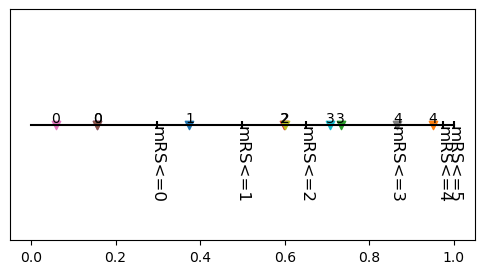

In [15]:
fig, ax = plt.subplots(figsize=(6, 3))

# Basic line:
ax.plot((0, 1), (0, 0), color='k')

# mRS bands:
for mrs, p in enumerate(mrs_cprobs):
    ax.scatter(p, 0, marker='|', color='k')
    ax.annotate(f'mRS<={mrs}', (p, 0), va='top', ha='center', fontsize=12, rotation=-90)

# Generated x:
for i, x in enumerate(x_values):
    # Draw marker:
    ax.scatter(x, 0.0, marker='v')
    # Label with assigned mRS:
    mrs = x_mrs.iloc[i]
    ax.annotate(mrs, (x, 0.0), va='bottom', ha='center')

ax.yaxis.set_visible(False)
plt.show()

Values of "x" 

## Utility conversion

Set up a dictionary of mRS to utility using the Dijkland values:

In [16]:
util_scores = dict(zip(range(7), [0.95, 0.93, 0.83, 0.62, 0.42, 0.11, 0.0]))

util_scores

{0: 0.95, 1: 0.93, 2: 0.83, 3: 0.62, 4: 0.42, 5: 0.11, 6: 0.0}

Convert our generated mRS scores to utility:

In [17]:
x_util = x_mrs.map(util_scores)

In [18]:
x_util

0    0.93
1    0.42
2    0.62
3    0.83
4    0.95
5    0.95
6    0.95
7    0.42
8    0.83
9    0.62
dtype: float64

## Gather patient data

In [19]:
df = pd.DataFrame()

df['x'] = x_values
df['x_inds'] = x_inds
df['mrs'] = x_mrs
df['util'] = x_util

In [20]:
df

,x,x_inds,mrs,util
0,0.37454,1,1,0.93
1,0.95071,4,4,0.42
2,0.73199,3,3,0.62
3,0.59866,2,2,0.83
4,0.15602,0,0,0.95
5,0.15599,0,0,0.95
6,0.05808,0,0,0.95
7,0.86618,4,4,0.42
8,0.60112,2,2,0.83
9,0.70807,3,3,0.62
